# 02 - Preprocessing

Prepares the data so the models in notebooks 03 and 04 can load it directly.

1. **Load & verify** - confirm shapes and anomaly rate match EDA
2. **Train/val split** - temporal 80/20 (no shuffling - time series)
3. **Scaling** - `RobustScaler` fit on nominal training rows only
4. **Sliding windows** - 3D arrays `(n_windows, 100, 58)` for reconstruction models
5. **Save** - arrays to `data/processed/`, scaler to `models/`
6. **Sanity checks** - shapes, NaN/Inf, label alignment

---
### Design decisions

| Decision | Choice | Why |
|---|---|---|
| Features | 58 target channels | Defined in `target_channels.csv`; channels 4–11 are pre-differenced counters; channels 1–3 / 53–56 / 67–69 excluded |
| Scaler | `RobustScaler` (median/IQR) | Robust to the ~10% anomalous samples that would skew a standard scaler |
| Split | Temporal 80/20 | Random split would let future data leak into training |
| Training data | Nominal rows only | The model learns what “normal” looks like; anomalies show up as high reconstruction error |
| `WINDOW_SIZE` | 100 rows | ~50 minutes of telemetry per window - enough temporal context |
| `TRAIN_STRIDE` | 100 (non-overlapping) | ~105k training windows, full coverage, no redundancy |
| Saved formats | 3D tensors for training, 2D arrays for inference | Training tensors go straight into `model.fit()`; inference windows are created on-the-fly to save disk space |

---
## 0 - Imports

In [8]:
import sys, gc, json, pickle, time
sys.path.insert(0, '../src')

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.preprocessing import RobustScaler

from sentinel.ml_logic.data import (
    load_train, load_test, load_target_channels,
    find_anomaly_segments, RAW_DIR, PROCESSED_DIR
)
from sentinel.params import RANDOM_STATE, TRAIN_RATIO, WINDOW_SIZE, TRAIN_STRIDE, ANOMALY_COLOR, NOMINAL_COLOR

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 110, 'font.size': 10})
MODELS_DIR = Path('../models')
MODELS_DIR.mkdir(exist_ok=True)
PROCESSED_DIR.mkdir(exist_ok=True)

np.random.seed(RANDOM_STATE)

print('Setup complete.')

Setup complete.


---
## 1 - Load & Recap

In [9]:
print('Loading train …')
t0 = time.time()
train = load_train()
test  = load_test()
target_channels = load_target_channels()          # 58 channels
print(f'  loaded in {time.time()-t0:.1f}s')

N_TRAIN   = len(train)
N_TEST    = len(test)
N_FEAT    = len(target_channels)                  # 58
N_ANOM    = int(train['is_anomaly'].sum())
N_NOMINAL = N_TRAIN - N_ANOM

print()
print(f'Train rows        : {N_TRAIN:>12,}')
print(f'Test  rows        : {N_TEST:>12,}')
print(f'Feature channels  : {N_FEAT}')
print(f'Anomaly samples   : {N_ANOM:>12,}  ({N_ANOM/N_TRAIN*100:.2f}%)')
print(f'Nominal samples   : {N_NOMINAL:>12,}  ({N_NOMINAL/N_TRAIN*100:.2f}%)')
print(f'Anomaly events    : {len(find_anomaly_segments(train["is_anomaly"]))} segments')

Loading train …
  loaded in 2.9s

Train rows        :   14,728,321
Test  rows        :      521,280
Feature channels  : 58
Anomaly samples   :    1,544,104  (10.48%)
Nominal samples   :   13,184,217  (89.52%)
Anomaly events    : 190 segments


In [10]:
# ── Confirm channels 4–11 are NOT in target_channels ─────────────────────────
ch4_11 = [f'channel_{i}' for i in range(4, 12)]
in_target = [c for c in ch4_11 if c in target_channels]
print(f'Channels 4–11 in target list: {in_target if in_target else "None ✓"}')
print('(These are pre-differenced derivatives of monotonic counters - correctly excluded.)')

# ── Confirm test IDs continue from train ─────────────────────────────────────
print(f'\nTrain ID range : {train["id"].min():,} → {train["id"].max():,}')
print(f'Test  ID range : {test["id"].min():,} → {test["id"].max():,}')
assert test['id'].min() == train['id'].max() + 1, 'IDs not contiguous!'
print('ID continuity  : ✓')

Channels 4–11 in target list: None ✓
(These are pre-differenced derivatives of monotonic counters - correctly excluded.)

Train ID range : 0 → 14,728,320
Test  ID range : 14,728,321 → 15,249,600
ID continuity  : ✓


---
## 2 - Train / Val Split

In [11]:
SPLIT_IDX = int(N_TRAIN * TRAIN_RATIO)

# ── Temporal slices of the full dataframe ────────────────────────────────────
train_full_df = train                                  # all rows, kept for threshold tuning
train_df      = train.iloc[:SPLIT_IDX]                 # first 80%
val_df        = train.iloc[SPLIT_IDX:]                 # last 20%

# ── Semi-supervised: extract NOMINAL rows for scaler fit ─────────────────────
nom_mask_train = train_df['is_anomaly'] == 0
nom_mask_val   = val_df['is_anomaly']   == 0

nom_train_df = train_df[nom_mask_train]
nom_val_df   = val_df  [nom_mask_val]

print(f'Split index        : {SPLIT_IDX:,}  (row {SPLIT_IDX/N_TRAIN*100:.0f}%)')
print()
print(f'train_df   rows    : {len(train_df):,}  | anomaly rows: {train_df["is_anomaly"].sum():,}')
print(f'val_df     rows    : {len(val_df):,}  | anomaly rows: {val_df["is_anomaly"].sum():,}')
print()
print(f'nom_train  rows    : {len(nom_train_df):,}  ({len(nom_train_df)/len(train_df)*100:.1f}% of train)')
print(f'nom_val    rows    : {len(nom_val_df):,}  ({len(nom_val_df)/len(val_df)*100:.1f}% of val)')

Split index        : 11,782,656  (row 80%)

train_df   rows    : 11,782,656  | anomaly rows: 1,233,929
val_df     rows    : 2,945,665  | anomaly rows: 310,175

nom_train  rows    : 10,548,727  (89.5% of train)
nom_val    rows    : 2,635,490  (89.5% of val)


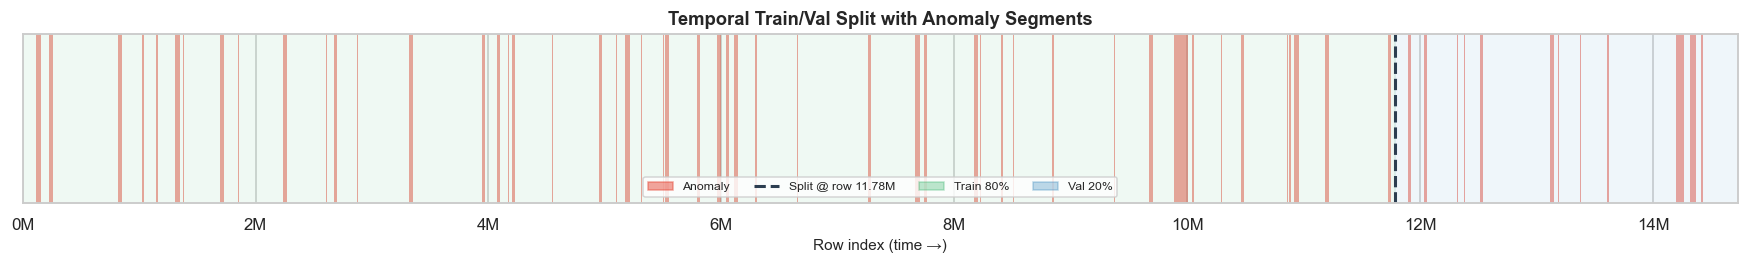

In [12]:
# ── Visualise the split boundary on the anomaly timeline ─────────────────────
import matplotlib.patches as mpatches

segments = find_anomaly_segments(train['is_anomaly'])

fig, ax = plt.subplots(figsize=(16, 2.5))

for seg in segments:
    ax.axvspan(seg['start'], seg['end'], color=ANOMALY_COLOR, alpha=0.5, linewidth=0)

ax.axvline(SPLIT_IDX, color='#2c3e50', lw=2, ls='--', label=f'Split boundary (row {SPLIT_IDX/1e6:.1f}M)')
ax.fill_betweenx([0, 1], 0, SPLIT_IDX, alpha=0.07, color='#27ae60', label='Train (80%)')
ax.fill_betweenx([0, 1], SPLIT_IDX, N_TRAIN, alpha=0.07, color='#2980b9', label='Val (20%)')

ax.set_xlim(0, N_TRAIN)
ax.set_ylim(0, 1)
ax.set_yticks([])
ax.set_xlabel('Row index (time →)', fontsize=10)
ax.set_title('Temporal Train/Val Split with Anomaly Segments', fontweight='bold', fontsize=12)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e6:.0f}M'))

handles = [
    mpatches.Patch(color=ANOMALY_COLOR, alpha=0.5, label='Anomaly'),
    plt.Line2D([0], [0], color='#2c3e50', lw=2, ls='--', label=f'Split @ row {SPLIT_IDX/1e6:.2f}M'),
    mpatches.Patch(color='#27ae60', alpha=0.3, label='Train 80%'),
    mpatches.Patch(color='#2980b9', alpha=0.3, label='Val 20%'),
]
ax.legend(handles=handles, fontsize=8, ncol=4)
fig.tight_layout()
plt.show()

---
## 3 - Normalisation

In [13]:
# ── Fit RobustScaler on NOMINAL TRAINING rows only ────────────────────────────
# RobustScaler uses median and IQR → robust to extreme anomaly values
# and to the non-stationarity of a 14-year telemetry series.

print('Fitting RobustScaler on nominal training rows …')
scaler = RobustScaler()
scaler.fit(nom_train_df[target_channels].values.astype(np.float32))
print('  done.')

# ── Save scaler immediately ────────────────────────────────────────────────────
scaler_path = MODELS_DIR / 'robust_scaler.pkl'
with open(scaler_path, 'wb') as f:
    pickle.dump(scaler, f)
print(f'  scaler saved → {scaler_path}')

Fitting RobustScaler on nominal training rows …
  done.
  scaler saved → ../models/robust_scaler.pkl


In [14]:
# ── Transform all splits - keep float32 to halve memory vs float64 ────────────
print('Scaling nominal train  …', end=' ')
nom_train_scaled = scaler.transform(
    nom_train_df[target_channels].values.astype(np.float32)
).astype(np.float32)
print(f'{nom_train_scaled.shape}  {nom_train_scaled.nbytes/1e9:.2f} GB')

print('Scaling nominal val    …', end=' ')
nom_val_scaled = scaler.transform(
    nom_val_df[target_channels].values.astype(np.float32)
).astype(np.float32)
print(f'{nom_val_scaled.shape}  {nom_val_scaled.nbytes/1e9:.2f} GB')

print('Scaling full train     …', end=' ')
train_full_scaled = scaler.transform(
    train_full_df[target_channels].values.astype(np.float32)
).astype(np.float32)
print(f'{train_full_scaled.shape}  {train_full_scaled.nbytes/1e9:.2f} GB')

print('Scaling test           …', end=' ')
test_scaled = scaler.transform(
    test[target_channels].values.astype(np.float32)
).astype(np.float32)
print(f'{test_scaled.shape}  {test_scaled.nbytes/1e9:.2f} GB')

Scaling nominal train  … (10548727, 58)  2.45 GB
Scaling nominal val    … (2635490, 58)  0.61 GB
Scaling full train     … (14728321, 58)  3.42 GB
Scaling test           … (521280, 58)  0.12 GB


In [15]:
# ── Free the raw dataframes - no longer needed ────────────────────────────────
y_train_full = train_full_df['is_anomaly'].values.astype(np.int8)
test_ids     = test['id'].values.astype(np.int64)

del train, train_full_df, train_df, val_df
del nom_train_df, nom_val_df
del test
gc.collect()
print('Raw dataframes freed. Current scaled arrays in memory:')
for name, arr in [
    ('nom_train_scaled', nom_train_scaled),
    ('nom_val_scaled',   nom_val_scaled),
    ('train_full_scaled',train_full_scaled),
    ('test_scaled',      test_scaled),
    ('y_train_full',     y_train_full),
    ('test_ids',         test_ids),
]:
    print(f'  {name:<22} {str(arr.shape):<25} {arr.nbytes/1e6:.1f} MB')

Raw dataframes freed. Current scaled arrays in memory:
  nom_train_scaled       (10548727, 58)            2447.3 MB
  nom_val_scaled         (2635490, 58)             611.4 MB
  train_full_scaled      (14728321, 58)            3417.0 MB
  test_scaled            (521280, 58)              120.9 MB
  y_train_full           (14728321,)               14.7 MB
  test_ids               (521280,)                 4.2 MB


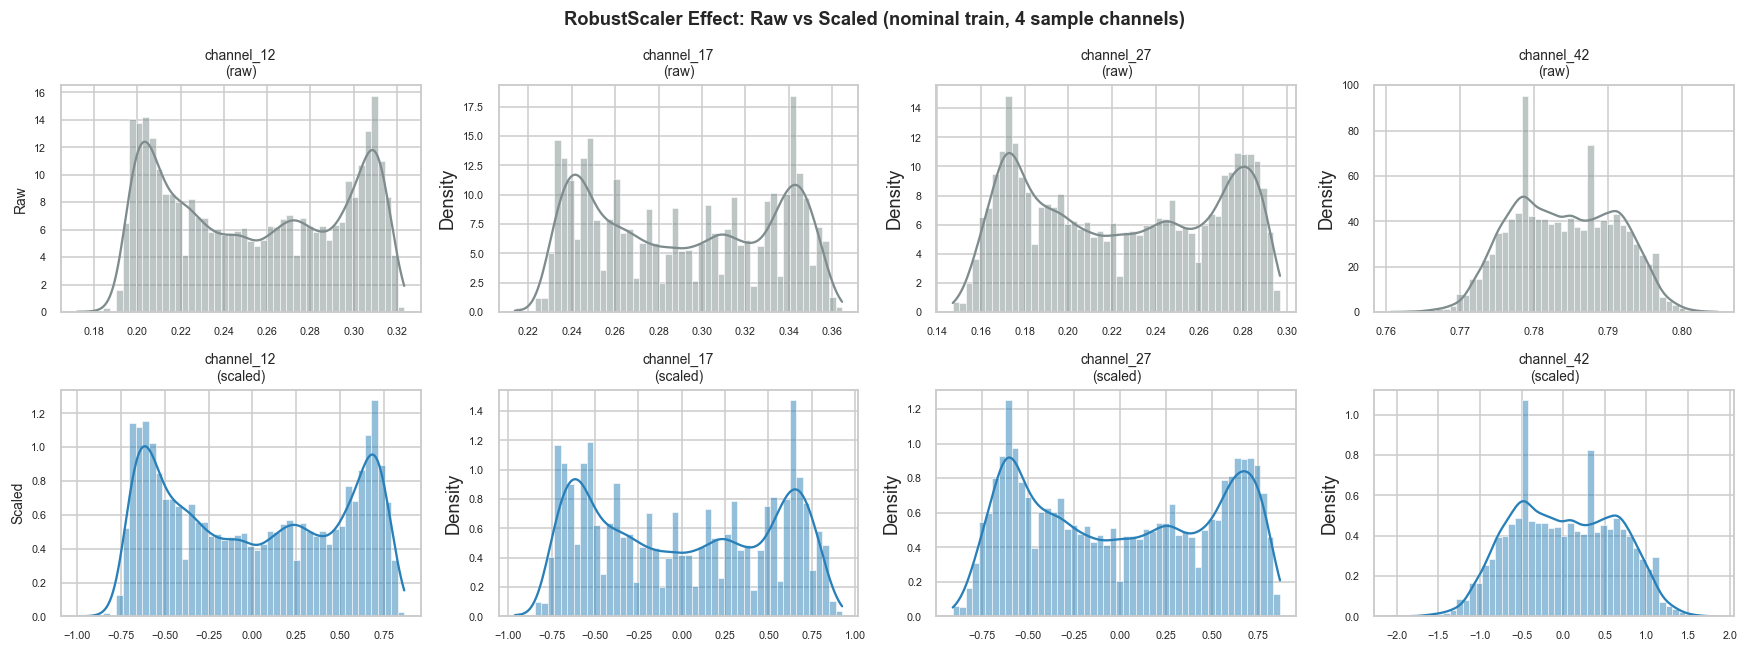

13524

In [16]:
# ── Visualise scaling effect: before vs after on 4 sample channels ────────────
SAMPLE_CHANNELS = [0, 5, 15, 30]   # indices into target_channels list
ch_names = [target_channels[i] for i in SAMPLE_CHANNELS]

sample_n = 50_000
idx = np.random.choice(len(nom_train_scaled), sample_n, replace=False)

fig, axes = plt.subplots(2, len(SAMPLE_CHANNELS), figsize=(16, 6))

# Reload raw values for comparison (only nominal train portion, just these cols)
raw_vals = load_train()  # reload just to sample - small cost compared to illustrating
tc = load_target_channels()
raw_nom = raw_vals[raw_vals['is_anomaly']==0][tc].values[:len(nom_train_scaled)]
del raw_vals; gc.collect()

for j, (ci, ch) in enumerate(zip(SAMPLE_CHANNELS, ch_names)):
    ax_raw   = axes[0, j]
    ax_scale = axes[1, j]

    sns.histplot(raw_nom[idx, ci],           ax=ax_raw,   bins=50, color='#7f8c8d',
                 stat='density', kde=True)
    sns.histplot(nom_train_scaled[idx, ci],  ax=ax_scale, bins=50, color='#2980b9',
                 stat='density', kde=True)

    ax_raw.set_title(f'{ch}\n(raw)',    fontsize=9)
    ax_scale.set_title(f'{ch}\n(scaled)', fontsize=9)
    for ax in (ax_raw, ax_scale):
        ax.set_xlabel('')
        ax.tick_params(labelsize=7)

axes[0, 0].set_ylabel('Raw', fontsize=9)
axes[1, 0].set_ylabel('Scaled', fontsize=9)
fig.suptitle('RobustScaler Effect: Raw vs Scaled (nominal train, 4 sample channels)',
             fontsize=12, fontweight='bold')
fig.tight_layout()
plt.show()

del raw_nom; gc.collect()

---
## 4 - Sliding Windows

### Window strategy

```
  time  →  [ t   t+1  t+2  …  t+99 ]    window i   (size=100)
  time  →  [ t+S t+S+1 …  t+S+99  ]    window i+1 (stride S)
```

**Window label**: `y[i] = 1` if **any** of the 100 samples inside the window is anomalous.  

**Training arrays** (`TRAIN_STRIDE=100`, non-overlapping) are pre-computed here and saved as 3D tensors - ready for `model.fit(X_train_nom)`.  

**Inference arrays** (val full, test) are saved as **2D scaled values** (n_rows × 58). During inference in notebook 03/04, sliding windows are created on-the-fly with `stride=1` in batches, which avoids materialising multi-GB tensors to disk while still producing a per-row reconstruction error.

In [17]:
def create_windows(
    data: np.ndarray,
    window_size: int,
    stride: int,
    labels: np.ndarray | None = None,
) -> tuple[np.ndarray, np.ndarray | None]:
    """
    Slice a 2D time series (n_rows × n_features) into 3D windows.

    Parameters
    ----------
    data        : float32 array  (n_rows, n_features)
    window_size : timesteps per window
    stride      : step between consecutive windows
    labels      : optional int8 array (n_rows,)  - if provided, window label
                  is 1 if ANY sample in the window is anomalous.

    Returns
    -------
    X : float32 (n_windows, window_size, n_features)
    y : int8    (n_windows,)  or None
    """
    n_rows, n_feat = data.shape
    n_windows = (n_rows - window_size) // stride + 1

    # Pre-allocate output
    X = np.empty((n_windows, window_size, n_feat), dtype=np.float32)
    y = np.empty(n_windows, dtype=np.int8) if labels is not None else None

    for i in range(n_windows):
        start = i * stride
        X[i]  = data[start : start + window_size]
        if labels is not None:
            y[i] = int(labels[start : start + window_size].max())

    return X, y


print('create_windows() defined.')
# Quick smoke-test
# Quick smoke-test: 250 rows, window=100, stride=50 → n_windows=(250-100)//50+1 = 4
_d = np.random.randn(250, 58).astype(np.float32)
_l = np.zeros(250, dtype=np.int8); _l[110:130] = 1
_X, _y = create_windows(_d, window_size=100, stride=50, labels=_l)
assert _X.shape == (4, 100, 58), f'Expected (4,100,58), got {_X.shape}'
assert _y[2] == 1, 'window 2 (rows 100-199) should overlap anomaly (110-129)'
assert _y[0] == 0, 'window 0 (rows 0-99) should be nominal'
print(f'Smoke test passed: X.shape={_X.shape}, y={_y}')
del _d, _l, _X, _y

create_windows() defined.
Smoke test passed: X.shape=(4, 100, 58), y=[0 1 1 0]


In [18]:
# ── X_train_nom - nominal training windows ────────────────────────────────────
# stride = TRAIN_STRIDE = 100 (non-overlapping): covers the entire 10.5M-row
# nominal training set with ~105k distinct windows.

print(f'Creating X_train_nom  (stride={TRAIN_STRIDE}) …')
t0 = time.time()
X_train_nom, _ = create_windows(nom_train_scaled, WINDOW_SIZE, TRAIN_STRIDE)
print(f'  shape   : {X_train_nom.shape}')
print(f'  memory  : {X_train_nom.nbytes/1e9:.2f} GB')
print(f'  time    : {time.time()-t0:.1f}s')

Creating X_train_nom  (stride=100) …
  shape   : (105487, 100, 58)
  memory  : 2.45 GB
  time    : 1.6s


In [19]:
# ── X_val_nom - nominal validation windows ────────────────────────────────────
print(f'Creating X_val_nom    (stride={TRAIN_STRIDE}) …')
t0 = time.time()
X_val_nom, _ = create_windows(nom_val_scaled, WINDOW_SIZE, TRAIN_STRIDE)
print(f'  shape   : {X_val_nom.shape}')
print(f'  memory  : {X_val_nom.nbytes/1e9:.2f} GB')
print(f'  time    : {time.time()-t0:.1f}s')

Creating X_val_nom    (stride=100) …
  shape   : (26354, 100, 58)
  memory  : 0.61 GB
  time    : 0.5s


In [20]:
# ── X_train_full + y_train_full - all train rows, windowed ───────────────────
# Used for threshold tuning: run the fitted PCA model over the labelled
# training data and pick the reconstruction-error threshold that maximises F0.5.

print(f'Creating X_train_full (stride={TRAIN_STRIDE}) …')
t0 = time.time()
X_train_full, y_train_full_win = create_windows(
    train_full_scaled, WINDOW_SIZE, TRAIN_STRIDE, labels=y_train_full
)
print(f'  X shape : {X_train_full.shape}')
print(f'  y shape : {y_train_full_win.shape}')
print(f'  memory  : {(X_train_full.nbytes + y_train_full_win.nbytes)/1e9:.2f} GB')
print(f'  time    : {time.time()-t0:.1f}s')
print(f'  anomaly windows : {y_train_full_win.sum():,}  ({y_train_full_win.mean()*100:.1f}%)')

Creating X_train_full (stride=100) …
  X shape : (147283, 100, 58)
  y shape : (147283,)
  memory  : 3.42 GB
  time    : 3.3s
  anomaly windows : 15,638  (10.6%)


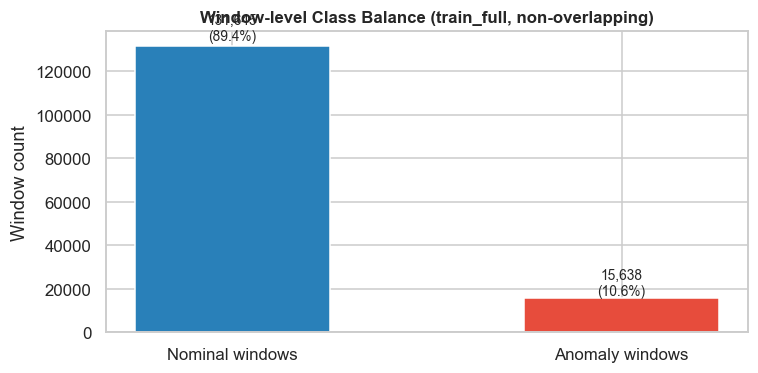

In [21]:
# ── Window-level label distribution ──────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 3.5))
counts = pd.Series({'Nominal windows': (y_train_full_win == 0).sum(),
                    'Anomaly windows':  (y_train_full_win == 1).sum()})
colors = ['#2980b9', '#e74c3c']
bars = ax.bar(counts.index, counts.values, color=colors, edgecolor='white', width=0.5)
for b, v in zip(bars, counts.values):
    ax.text(b.get_x() + b.get_width()/2, b.get_height()*1.01,
            f'{v:,}\n({v/counts.sum()*100:.1f}%)', ha='center', va='bottom', fontsize=9)
ax.set_title('Window-level Class Balance (train_full, non-overlapping)',
             fontweight='bold', fontsize=11)
ax.set_ylabel('Window count')
fig.tight_layout()
plt.show()

In [22]:
# ── Free intermediate arrays no longer needed before saving ──────────────────
del nom_train_scaled, nom_val_scaled
gc.collect()
print('Intermediate scaled arrays freed.')

Intermediate scaled arrays freed.


---
## 5 - Save Processed Arrays

In [23]:
# ── File manifest ─────────────────────────────────────────────────────────────
#
#  3D training tensors (pre-computed, feed directly to model.fit):
#    X_train_nom.npy     (n_win, 100, 58)  float32   nominal train windows
#    X_val_nom.npy       (n_win, 100, 58)  float32   nominal val windows
#    X_train_full.npy    (n_win, 100, 58)  float32   all train windows (threshold tuning)
#    y_train_full.npy    (n_win,)          int8      window-level labels
#
#  2D inference arrays (windows created on-the-fly at inference time):
#    train_full_scaled.npy   (14_728_321, 58)  float32
#    y_train_row.npy         (14_728_321,)     int8      row-level labels
#    test_scaled.npy         (   521_280, 58)  float32
#    test_ids.npy            (   521_280,)     int64     for submission mapping

save_manifest = {
    'X_train_nom.npy'       : X_train_nom,
    'X_val_nom.npy'         : X_val_nom,
    'X_train_full.npy'      : X_train_full,
    'y_train_full.npy'      : y_train_full_win,
    'train_full_scaled.npy' : train_full_scaled,
    'y_train_row.npy'       : y_train_full,
    'test_scaled.npy'       : test_scaled,
    'test_ids.npy'          : test_ids,
}

total_bytes = 0
for fname, arr in save_manifest.items():
    path = PROCESSED_DIR / fname
    print(f'  saving {fname:<30} {str(arr.shape):<25} {arr.nbytes/1e6:>8.1f} MB …', end=' ')
    t0 = time.time()
    np.save(path, arr)
    total_bytes += arr.nbytes
    print(f'{time.time()-t0:.1f}s')

print(f'\nTotal saved : {total_bytes/1e9:.2f} GB')

  saving X_train_nom.npy                (105487, 100, 58)           2447.3 MB … 2.7s
  saving X_val_nom.npy                  (26354, 100, 58)             611.4 MB … 0.8s
  saving X_train_full.npy               (147283, 100, 58)           3417.0 MB … 3.7s
  saving y_train_full.npy               (147283,)                      0.1 MB … 0.0s
  saving train_full_scaled.npy          (14728321, 58)              3417.0 MB … 19.2s
  saving y_train_row.npy                (14728321,)                   14.7 MB … 0.0s
  saving test_scaled.npy                (521280, 58)                 120.9 MB … 0.9s
  saving test_ids.npy                   (521280,)                      4.2 MB … 0.0s

Total saved : 10.03 GB


In [24]:
# ── Save preprocessing configuration as JSON ─────────────────────────────────
config = {
    'window_size'       : WINDOW_SIZE,
    'train_stride'      : TRAIN_STRIDE,
    'train_ratio'       : TRAIN_RATIO,
    'split_idx'         : SPLIT_IDX,
    'n_features'        : N_FEAT,
    'target_channels'   : target_channels,
    'n_train_rows'      : N_TRAIN,
    'n_test_rows'       : N_TEST,
    'n_anomaly_rows'    : int(N_ANOM),
    'n_nominal_rows'    : int(N_NOMINAL),
    'shapes': {
        'X_train_nom'       : list(X_train_nom.shape),
        'X_val_nom'         : list(X_val_nom.shape),
        'X_train_full'      : list(X_train_full.shape),
        'y_train_full'      : list(y_train_full_win.shape),
        'train_full_scaled' : list(train_full_scaled.shape),
        'y_train_row'       : list(y_train_full.shape),
        'test_scaled'       : list(test_scaled.shape),
        'test_ids'          : list(test_ids.shape),
    },
}

config_path = PROCESSED_DIR / 'preprocessing_config.json'
with open(config_path, 'w') as f:
    json.dump(config, f, indent=2)

print(f'Config saved → {config_path}')
print(json.dumps({k: v for k, v in config.items() if k != 'target_channels'}, indent=2))

Config saved → /Users/helena.schulz.ext/code/helenaschulz/sentinel/data/processed/preprocessing_config.json
{
  "window_size": 100,
  "train_stride": 100,
  "train_ratio": 0.8,
  "split_idx": 11782656,
  "n_features": 58,
  "n_train_rows": 14728321,
  "n_test_rows": 521280,
  "n_anomaly_rows": 1544104,
  "n_nominal_rows": 13184217,
  "shapes": {
    "X_train_nom": [
      105487,
      100,
      58
    ],
    "X_val_nom": [
      26354,
      100,
      58
    ],
    "X_train_full": [
      147283,
      100,
      58
    ],
    "y_train_full": [
      147283
    ],
    "train_full_scaled": [
      14728321,
      58
    ],
    "y_train_row": [
      14728321
    ],
    "test_scaled": [
      521280,
      58
    ],
    "test_ids": [
      521280
    ]
  }
}


---
## 6 - Sanity Checks

In [25]:
# ── 6.1 Shape verification ────────────────────────────────────────────────────
print('=== Shape checks ===')

checks = [
    # name,          array,              expected_ndim,  expected_dtype
    ('X_train_nom',      X_train_nom,      3, np.float32),
    ('X_val_nom',        X_val_nom,        3, np.float32),
    ('X_train_full',     X_train_full,     3, np.float32),
    ('y_train_full',     y_train_full_win, 1, np.int8),
    ('train_full_scaled',train_full_scaled,2, np.float32),
    ('y_train_row',      y_train_full,     1, np.int8),
    ('test_scaled',      test_scaled,      2, np.float32),
    ('test_ids',         test_ids,         1, np.int64),
]

all_ok = True
for name, arr, ndim, dtype in checks:
    ok_dim   = '✓' if arr.ndim  == ndim  else f'✗ expected {ndim}D'
    ok_dtype = '✓' if arr.dtype == dtype else f'✗ expected {dtype}'
    print(f'  {name:<22} shape={str(arr.shape):<25} ndim={ok_dim}  dtype={ok_dtype}')
    if '✗' in ok_dim or '✗' in ok_dtype:
        all_ok = False

print(f'\nAll shape/dtype checks: {"✓ PASS" if all_ok else "✗ FAIL"}')

=== Shape checks ===
  X_train_nom            shape=(105487, 100, 58)         ndim=✓  dtype=✓
  X_val_nom              shape=(26354, 100, 58)          ndim=✓  dtype=✓
  X_train_full           shape=(147283, 100, 58)         ndim=✓  dtype=✓
  y_train_full           shape=(147283,)                 ndim=✓  dtype=✓
  train_full_scaled      shape=(14728321, 58)            ndim=✓  dtype=✓
  y_train_row            shape=(14728321,)               ndim=✓  dtype=✓
  test_scaled            shape=(521280, 58)              ndim=✓  dtype=✓
  test_ids               shape=(521280,)                 ndim=✓  dtype=✓

All shape/dtype checks: ✓ PASS


In [26]:
# ── 6.2 NaN / Inf check ───────────────────────────────────────────────────────
print('=== NaN / Inf checks ===')
all_clean = True
for name, arr, *_ in checks:
    if arr.dtype.kind == 'f':
        has_nan = bool(np.isnan(arr).any())
        has_inf = bool(np.isinf(arr).any())
        status  = '✓ clean' if not has_nan and not has_inf else f'✗ NaN={has_nan} Inf={has_inf}'
        print(f'  {name:<22} {status}')
        if has_nan or has_inf:
            all_clean = False
    else:
        print(f'  {name:<22} (integer - skipped)')
print(f'\nAll float arrays clean: {"✓ PASS" if all_clean else "✗ FAIL"}')

=== NaN / Inf checks ===
  X_train_nom            ✓ clean
  X_val_nom              ✓ clean
  X_train_full           ✓ clean
  y_train_full           (integer - skipped)
  train_full_scaled      ✓ clean
  y_train_row            (integer - skipped)
  test_scaled            ✓ clean
  test_ids               (integer - skipped)

All float arrays clean: ✓ PASS


In [27]:
# ── 6.3 Label alignment ───────────────────────────────────────────────────────
# Verify that X_train_full[i] corresponds to y_train_full_win[i]
print('=== Label alignment check ===')

# Spot check: pick 10 random anomalous windows and verify
anom_win_idx = np.where(y_train_full_win == 1)[0]
print(f'Anomaly windows: {len(anom_win_idx):,} / {len(y_train_full_win):,}')

rng = np.random.default_rng(RANDOM_STATE)
sample_idx = rng.choice(anom_win_idx, size=min(10, len(anom_win_idx)), replace=False)

mismatch = 0
for wi in sample_idx:
    row_start = wi * TRAIN_STRIDE
    row_end   = row_start + WINDOW_SIZE
    expected  = int(y_train_full[row_start:row_end].max())
    got       = int(y_train_full_win[wi])
    if expected != got:
        print(f'  MISMATCH at window {wi}: expected {expected}, got {got}')
        mismatch += 1

print(f'Spot-checked {len(sample_idx)} anomaly windows - mismatches: {mismatch}')

# Also verify X_train_nom has NO anomaly windows by construction
assert y_train_full_win[y_train_full_win == -1].sum() == 0, 'Unexpected label value'
print(f'Label values: {np.unique(y_train_full_win)} (only 0 and 1) ✓')
print(f'Label alignment: {"✓ PASS" if mismatch == 0 else "✗ FAIL"}')

=== Label alignment check ===
Anomaly windows: 15,638 / 147,283
Spot-checked 10 anomaly windows - mismatches: 0
Label values: [0 1] (only 0 and 1) ✓
Label alignment: ✓ PASS


In [28]:
# ── 6.4 Value range & distribution after scaling ─────────────────────────────
print('=== Scaled value range (nominal train windows) ===')
flat = X_train_nom.reshape(-1, N_FEAT)
p1, p99 = np.percentile(flat, [1, 99], axis=0)
print(f'P1  range across channels : [{p1.min():.2f}, {p1.max():.2f}]')
print(f'P99 range across channels : [{p99.min():.2f}, {p99.max():.2f}]')
print(f'Global min / max          : {flat.min():.2f} / {flat.max():.2f}')
del flat; gc.collect()

=== Scaled value range (nominal train windows) ===
P1  range across channels : [-1.78, 0.00]
P99 range across channels : [0.00, 2.00]
Global min / max          : -2.67 / 3.22


66

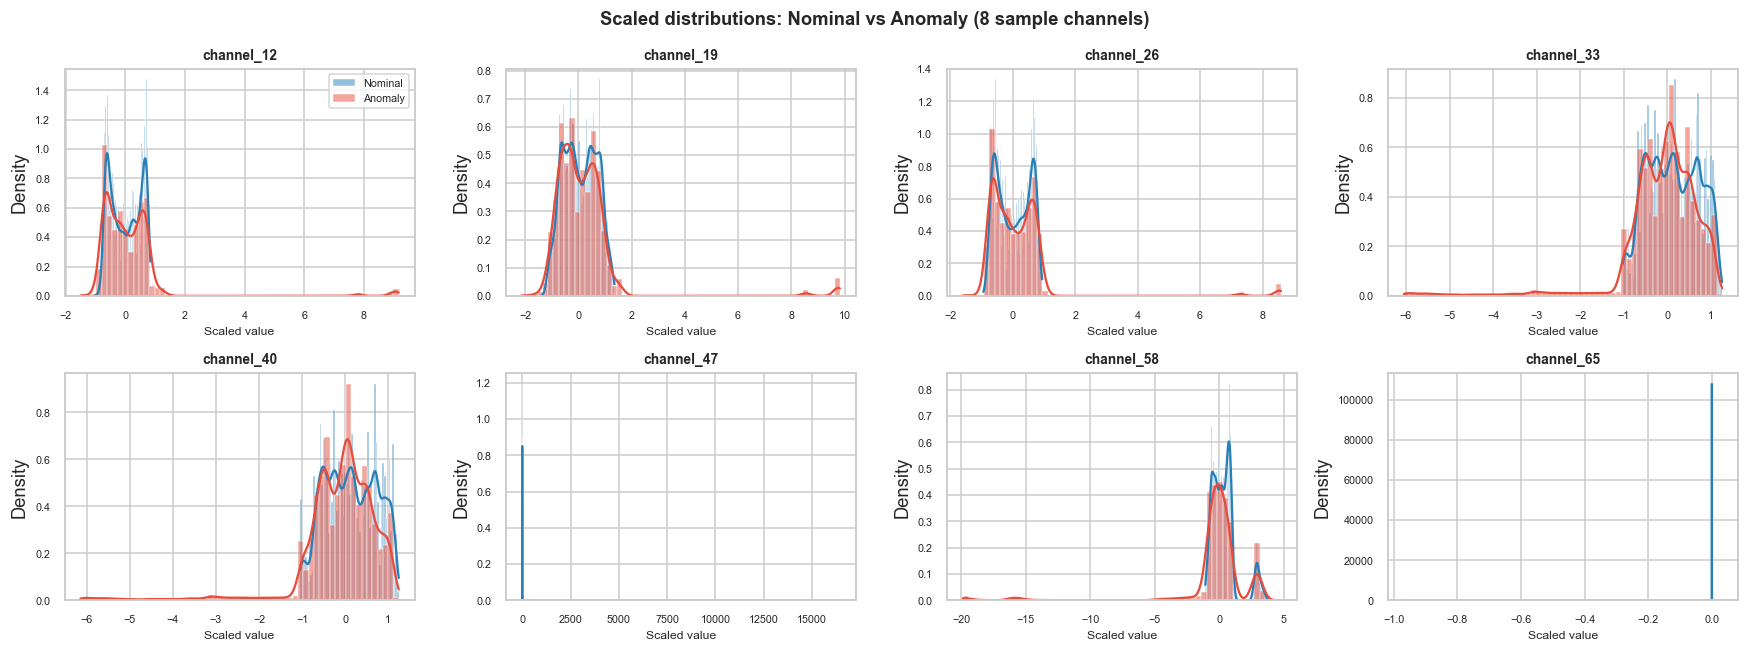

In [29]:
# ── 6.5 Distribution plots - 8 sample channels after scaling ─────────────────
PLOT_CHANNELS = list(range(0, N_FEAT, N_FEAT // 8))[:8]
ch_labels     = [target_channels[i] for i in PLOT_CHANNELS]

# Gather nominal vs anomaly scaled values
nom_mask  = y_train_full == 0
anom_mask = y_train_full == 1

NSAMP = 30_000
rng   = np.random.default_rng(RANDOM_STATE)

nom_idx  = rng.choice(np.where(nom_mask) [0], size=NSAMP, replace=False)
anom_idx = rng.choice(np.where(anom_mask)[0], size=min(NSAMP, anom_mask.sum()), replace=False)

fig, axes = plt.subplots(2, 4, figsize=(16, 6))
axes = axes.flatten()

for j, (ci, ch) in enumerate(zip(PLOT_CHANNELS, ch_labels)):
    ax = axes[j]
    nom_vals  = train_full_scaled[nom_idx,  ci]
    anom_vals = train_full_scaled[anom_idx, ci]
    sns.histplot(nom_vals,  ax=ax, color='#2980b9', alpha=0.5, stat='density',
                 bins=60, label='Nominal', kde=True)
    sns.histplot(anom_vals, ax=ax, color='#e74c3c', alpha=0.5, stat='density',
                 bins=60, label='Anomaly', kde=True)
    ax.set_title(ch, fontsize=9, fontweight='bold')
    ax.set_xlabel('Scaled value', fontsize=8)
    ax.tick_params(labelsize=7)
    if j == 0:
        ax.legend(fontsize=7)

fig.suptitle('Scaled distributions: Nominal vs Anomaly (8 sample channels)',
             fontsize=12, fontweight='bold')
fig.tight_layout()
plt.show()

In [30]:
# ── 6.6 Final file listing ────────────────────────────────────────────────────
import os
print(f'Contents of {PROCESSED_DIR}:')
for p in sorted(PROCESSED_DIR.glob('*')):
    size_mb = os.path.getsize(p) / 1e6
    print(f'  {p.name:<35} {size_mb:>10.1f} MB')

print(f'\nModels directory:')
for p in sorted(MODELS_DIR.glob('*')):
    size_mb = os.path.getsize(p) / 1e6
    print(f'  {p.name:<35} {size_mb:>10.1f} MB')

Contents of /Users/helena.schulz.ext/code/helenaschulz/sentinel/data/processed:
  .gitkeep                                   0.0 MB
  X_train_full.npy                        3417.0 MB
  X_train_nom.npy                         2447.3 MB
  X_val_nom.npy                            611.4 MB
  preprocessing_config.json                  0.0 MB
  test_ids.npy                               4.2 MB
  test_scaled.npy                          120.9 MB
  train_full_scaled.npy                   3417.0 MB
  y_train_full.npy                           0.1 MB
  y_train_row.npy                           14.7 MB

Models directory:
  .gitkeep                                   0.0 MB
  pca_baseline.pkl                           0.9 MB
  robust_scaler.pkl                          0.0 MB


In [31]:
# ── 6.7 Load-back round-trip verification ─────────────────────────────────────
print('Round-trip load check …')
for fname in ['X_train_nom.npy', 'X_val_nom.npy', 'y_train_full.npy', 'test_ids.npy']:
    loaded = np.load(PROCESSED_DIR / fname)
    print(f'  {fname:<30} loaded shape={loaded.shape}  dtype={loaded.dtype}  ✓')
    del loaded

with open(MODELS_DIR / 'robust_scaler.pkl', 'rb') as f:
    loaded_scaler = pickle.load(f)
print(f'  robust_scaler.pkl            loaded center[0]={loaded_scaler.center_[0]:.4f}  ✓')

print('\nAll round-trip checks passed ✓')

Round-trip load check …
  X_train_nom.npy                loaded shape=(105487, 100, 58)  dtype=float32  ✓
  X_val_nom.npy                  loaded shape=(26354, 100, 58)  dtype=float32  ✓
  y_train_full.npy               loaded shape=(147283,)  dtype=int8  ✓
  test_ids.npy                   loaded shape=(521280,)  dtype=int64  ✓
  robust_scaler.pkl            loaded center[0]=0.2532  ✓

All round-trip checks passed ✓


---
## Summary

| Array | Shape | Size | Purpose |
|---|---|---|---|
| `X_train_nom.npy` | `(~105k, 100, 58)` | ~2.4 GB | Nominal training windows for reconstruction model |
| `X_val_nom.npy` | `(~26k, 100, 58)` | ~0.6 GB | Nominal validation windows |
| `X_train_full.npy` | `(~147k, 100, 58)` | ~3.4 GB | Threshold tuning (labelled windows) |
| `y_train_full.npy` | `(~147k,)` | ~0.1 MB | Window labels: 1 if any sample anomalous |
| `train_full_scaled.npy` | `(14.7M, 58)` | ~3.4 GB | Per-row inference (stride-1 windows on-the-fly) |
| `y_train_row.npy` | `(14.7M,)` | ~14 MB | Row-level labels for event-wise F0.5 eval |
| `test_scaled.npy` | `(521k, 58)` | ~0.1 GB | Per-row test inference |
| `test_ids.npy` | `(521k,)` | ~4 MB | Submission ID mapping |
| `models/robust_scaler.pkl` | - | <1 MB | Fitted scaler (re-used at inference time) |

## Key findings

- The **temporal 80/20 split** places the boundary at row 11,782,656, giving 13.2M nominal training rows and a validation tail of 2.9M rows with 38 anomaly events - large enough for reliable threshold tuning.
- **RobustScaler** (fitted on the 13.2M nominal training rows only) reduces the influence of anomaly outliers on the scaling parameters; this is critical to avoid data leakage from anomaly periods into the feature scale.
- **Channels 4–11** were left as-is (not re-differenced) - ESA already differenced them before publishing.
- Non-overlapping windows (stride = 100) produce **105,487 nominal training windows** and **147,283 full training windows**; overlap-based scoring will be applied at inference time in downstream notebooks, not stored.
- All eight array round-trips (load → check shape and dtype) pass, confirming no corruption during save.

| Artefact | Shape | Notes |
|---|---|---|
| `X_train_nom.npy` | (105,487 × 100 × 58) | Nominal-only windows for model training |
| `X_train_full.npy` | (147,283 × 100 × 58) | All windows (including anomalous) |
| `train_full_scaled.npy` | (14,728,321 × 58) | Row-level, used for val scoring |
| `test_scaled.npy` | (521,280 × 58) | Row-level test features |
| `robust_scaler.pkl` | - | Fitted on nominal train rows only |
| Split index | 11,782,656 | Strict temporal boundary |

What this means for the next step: downstream notebooks should load row-level arrays (`train_full_scaled.npy`, `test_scaled.npy`) and create overlapping windows at scoring time; the nominal window array (`X_train_nom.npy`) is used only to fit the anomaly model.
